# Практическое задание №4

**Исследование временного ряда международных туристских прибытий
в макрорегион Asia and the Pacific, помесячно, 2019–2024 гг.**

Тема: *Post-COVID Reshaping of Tourism Seasonality in Asia and the Pacific:
Monthly International Tourist Arrivals, 2019–2024*.

Источник данных: UN Tourism (World Tourism Barometer, Statistical Annex,
диаграмма A-6 и таблица A-14).

## 1. Настройка окружения и загрузка данных

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import rcParams
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats

warnings.filterwarnings("ignore")

rcParams["font.family"] = "DejaVu Serif"
rcParams["font.size"] = 11
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3
rcParams["figure.dpi"] = 110
rcParams["savefig.dpi"] = 200
rcParams["savefig.bbox"] = "tight"

DATA_DIR = os.path.join("..", "data")
OUT_DIR = os.path.join(".", "generated")
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, "01_monthly_arrivals_cleaned_derived.csv"))
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

annual = pd.read_csv(os.path.join(DATA_DIR, "02_annual_summary.csv"))
season = pd.read_csv(os.path.join(DATA_DIR, "03_seasonality_profile.csv"))
acf_tab = pd.read_csv(os.path.join(DATA_DIR, "04_acf_values.csv"))
adf_tab = pd.read_csv(os.path.join(DATA_DIR, "05_stationarity_adf_tests.csv"))
out_tab = pd.read_csv(os.path.join(DATA_DIR, "07_outliers.csv"))

print(f"Период: {df['date'].min():%Y-%m} … {df['date'].max():%Y-%m}, "
      f"n = {len(df)}")

Период: 2019-01 … 2024-03, n = 63


## 2. Описательные характеристики

In [3]:
y_all = df["arrivals_million"].values
print(f"n      = {len(y_all)}")
print(f"min    = {np.min(y_all):.3f}")
print(f"max    = {np.max(y_all):.3f}")
print(f"mean   = {np.mean(y_all):.3f}")
print(f"median = {np.median(y_all):.3f}")
print(f"std    = {np.std(y_all, ddof=1):.3f}")
print(f"Q1     = {np.percentile(y_all, 25):.3f}")
print(f"Q3     = {np.percentile(y_all, 75):.3f}")

n      = 63
min    = 0.570
max    = 31.985
mean   = 13.574
median = 11.200
std    = 11.512
Q1     = 2.223
Q3     = 25.117


## 3. Рисунок 1. Помесячные прибытия 2019–2024

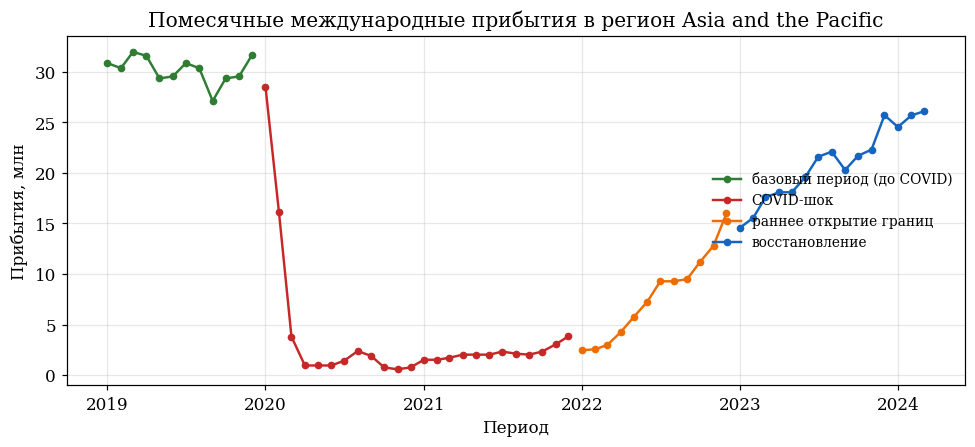

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.2))
phase_map = {
    "pre-COVID baseline": ("базовый период (до COVID)", "#2E7D32"),
    "COVID shock":        ("COVID-шок", "#C62828"),
    "early reopening":    ("раннее открытие границ", "#EF6C00"),
    "recovery":           ("восстановление", "#1565C0"),
}
for phase_key, (label_ru, color) in phase_map.items():
    sub = df[df["phase"] == phase_key]
    ax.plot(sub["date"], sub["arrivals_million"], "o-",
            color=color, markersize=4, linewidth=1.6, label=label_ru)
ax.set_xlabel("Период")
ax.set_ylabel("Прибытия, млн")
ax.set_title("Помесячные международные прибытия в регион Asia and the Pacific")
ax.legend(loc="center right", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig01_monthly_series.pdf"))
plt.show()

## 4. Рисунок 2. Годовые итоги

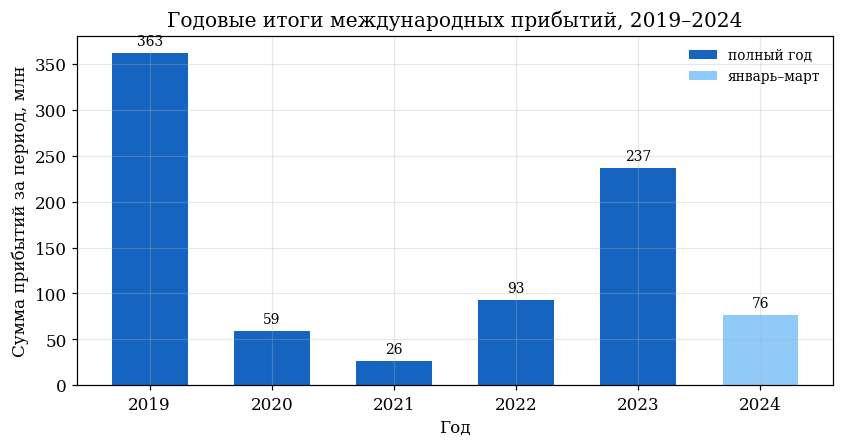

In [5]:
fig, ax = plt.subplots(figsize=(7.8, 4.2))
ann_full = annual[annual["note"] == "full year"]
ann_2024 = annual[annual["note"].str.startswith("Jan-Mar")]
bars1 = ax.bar(ann_full["year"].astype(str), ann_full["total_arrivals_million"],
               color="#1565C0", width=0.62, label="полный год")
bars2 = ax.bar(ann_2024["year"].astype(str), ann_2024["total_arrivals_million"],
               color="#90CAF9", width=0.62, label="январь–март")
for bar, val in zip(list(bars1) + list(bars2),
                    list(ann_full["total_arrivals_million"]) + list(ann_2024["total_arrivals_million"])):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, f"{val:.0f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Год")
ax.set_ylabel("Сумма прибытий за период, млн")
ax.set_title("Годовые итоги международных прибытий, 2019–2024")
ax.legend(loc="upper right", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig02_annual_totals.pdf"))
plt.show()

## 5. Рисунок 3. Сезонный профиль

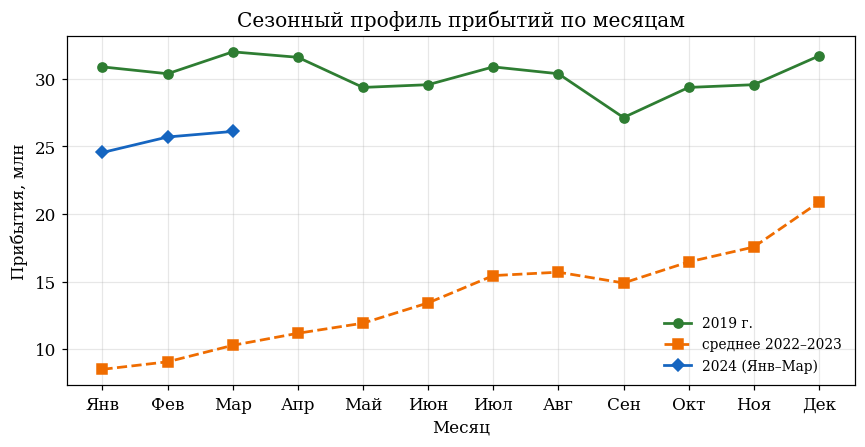

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.2))
months_ru = ["Янв", "Фев", "Мар", "Апр", "Май", "Июн",
             "Июл", "Авг", "Сен", "Окт", "Ноя", "Дек"]
ax.plot(months_ru, season["2019_baseline_million"], "o-",
        color="#2E7D32", label="2019 г.", linewidth=1.8)
ax.plot(months_ru, season["2022_2023_avg_million"], "s--",
        color="#EF6C00", label="среднее 2022–2023", linewidth=1.8)
ax.plot(months_ru[:3], season["2024_million"].dropna(), "D-",
        color="#1565C0", label="2024 (Янв–Мар)", linewidth=1.8)
ax.set_xlabel("Месяц")
ax.set_ylabel("Прибытия, млн")
ax.set_title("Сезонный профиль прибытий по месяцам")
ax.legend(loc="lower right", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig03_seasonal_profile.pdf"))
plt.show()

## 6. Рисунок 4. Гистограмма распределения уровней ряда

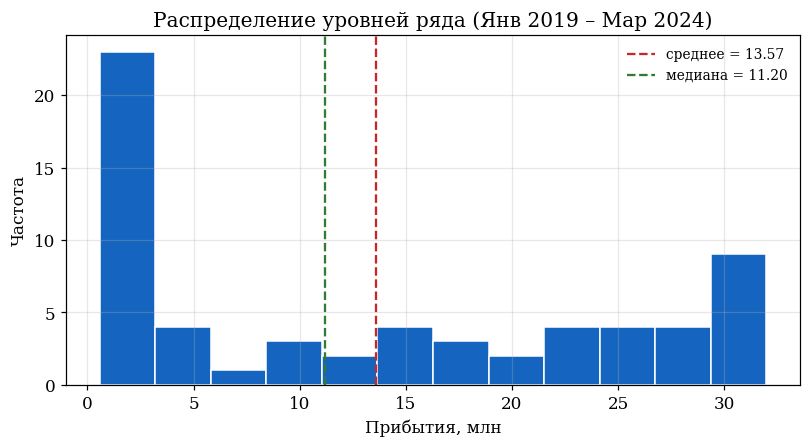

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.hist(y_all, bins=12, color="#1565C0", edgecolor="white")
ax.axvline(np.mean(y_all), color="#C62828", linestyle="--",
           linewidth=1.5, label=f"среднее = {np.mean(y_all):.2f}")
ax.axvline(np.median(y_all), color="#2E7D32", linestyle="--",
           linewidth=1.5, label=f"медиана = {np.median(y_all):.2f}")
ax.set_xlabel("Прибытия, млн")
ax.set_ylabel("Частота")
ax.set_title("Распределение уровней ряда (Янв 2019 – Мар 2024)")
ax.legend(loc="upper right", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig04_histogram.pdf"))
plt.show()

## 7. Стационарность и автокорреляция

In [8]:
y_2019_2023 = df[df["year"].between(2019, 2023)]["arrivals_million"].values

# Расширенный тест Дики–Фуллера на исходных уровнях
adf_raw = adfuller(y_2019_2023, autolag="AIC")
print("ADF на исходных уровнях:")
print(f"  статистика = {adf_raw[0]:.4f}")
print(f"  p-value    = {adf_raw[1]:.6f}")

# На первых разностях
diff1 = np.diff(y_2019_2023)
adf_d1 = adfuller(diff1, autolag="AIC")
print("\nADF на первых разностях:")
print(f"  статистика = {adf_d1[0]:.4f}")
print(f"  p-value    = {adf_d1[1]:.6f}")

ADF на исходных уровнях:
  статистика = -1.6352
  p-value    = 0.464787

ADF на первых разностях:
  статистика = -4.5359
  p-value    = 0.000169


## 8. Рисунок 5. Коррелограмма

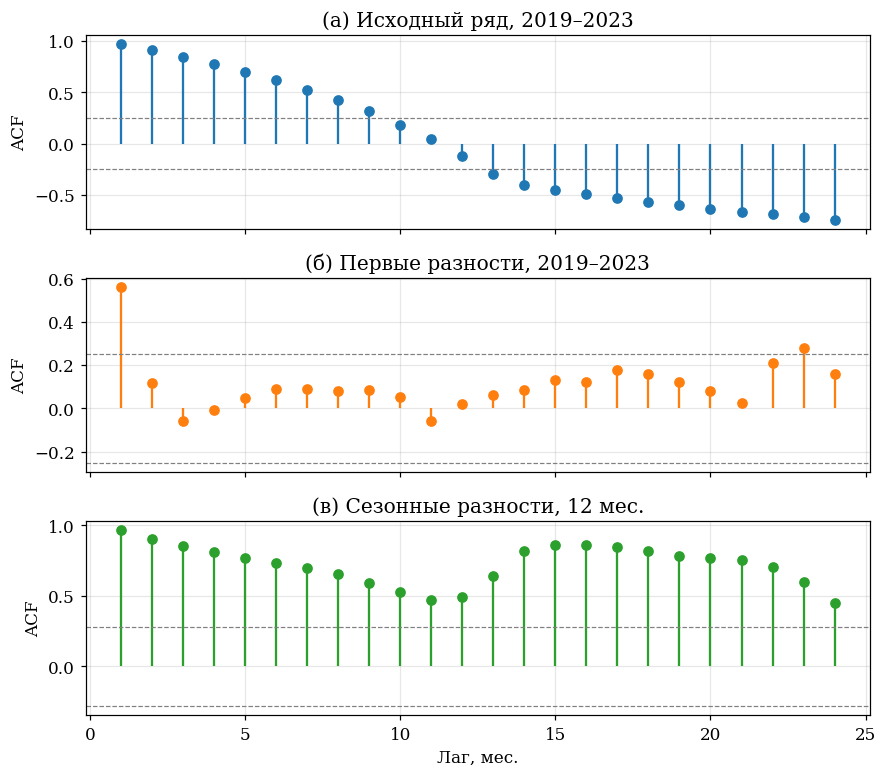

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(8.2, 7.2), sharex=True)

n0 = len(y_2019_2023)
ci0 = 1.96 / np.sqrt(n0)
axes[0].stem(range(1, len(acf_tab)+1), acf_tab["acf_raw_2019_2023"],
             linefmt="C0-", markerfmt="C0o", basefmt=" ")
axes[0].axhline(ci0, color="grey", linestyle="--", linewidth=0.8)
axes[0].axhline(-ci0, color="grey", linestyle="--", linewidth=0.8)
axes[0].set_title("(а) Исходный ряд, 2019–2023")
axes[0].set_ylabel("ACF")

axes[1].stem(range(1, len(acf_tab)+1), acf_tab["acf_first_difference"],
             linefmt="C1-", markerfmt="C1o", basefmt=" ")
axes[1].axhline(ci0, color="grey", linestyle="--", linewidth=0.8)
axes[1].axhline(-ci0, color="grey", linestyle="--", linewidth=0.8)
axes[1].set_title("(б) Первые разности, 2019–2023")
axes[1].set_ylabel("ACF")

n2 = 48
ci2 = 1.96 / np.sqrt(n2)
axes[2].stem(range(1, len(acf_tab)+1), acf_tab["acf_12_month_seasonal_difference"],
             linefmt="C2-", markerfmt="C2o", basefmt=" ")
axes[2].axhline(ci2, color="grey", linestyle="--", linewidth=0.8)
axes[2].axhline(-ci2, color="grey", linestyle="--", linewidth=0.8)
axes[2].set_title("(в) Сезонные разности, 12 мес.")
axes[2].set_ylabel("ACF")
axes[2].set_xlabel("Лаг, мес.")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig05_correlogram.pdf"))
plt.show()

## 9. Аддитивная декомпозиция ряда

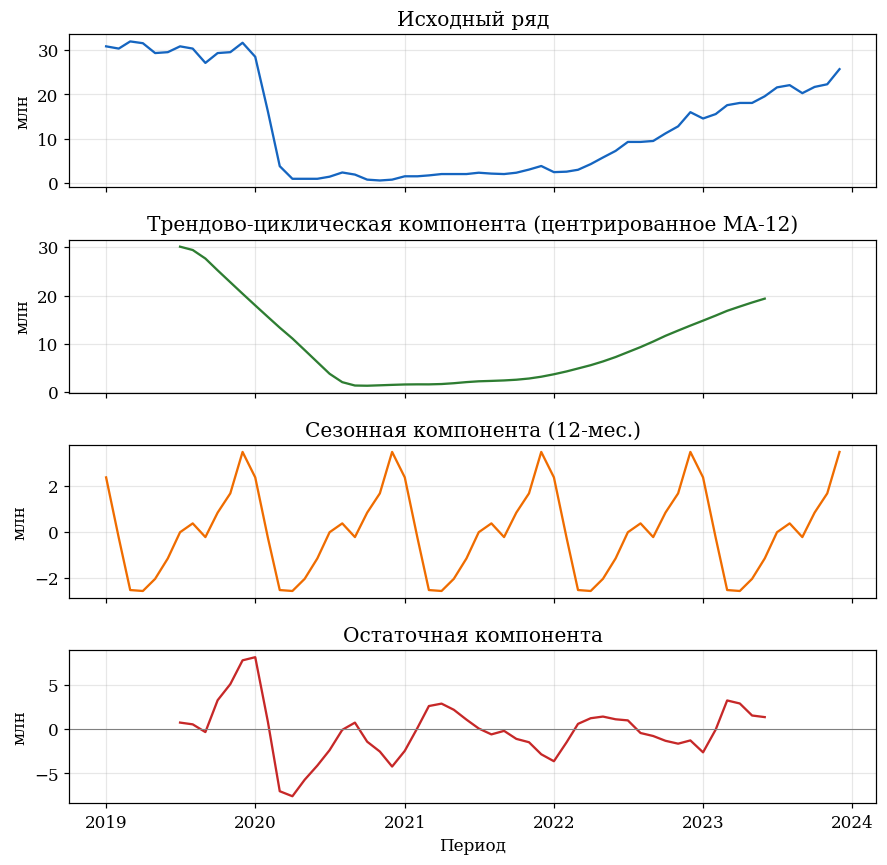

In [10]:
df_full = df[df["year"].between(2019, 2023)].copy().set_index("date")
ts = df_full["arrivals_million"]
result = seasonal_decompose(ts, model="additive", period=12, extrapolate_trend=0)

fig, axes = plt.subplots(4, 1, figsize=(8.2, 8.0), sharex=True)
axes[0].plot(ts.index, ts.values, color="#1565C0")
axes[0].set_title("Исходный ряд")
axes[0].set_ylabel("млн")

axes[1].plot(result.trend.index, result.trend.values, color="#2E7D32")
axes[1].set_title("Трендово-циклическая компонента (центрированное MA-12)")
axes[1].set_ylabel("млн")

axes[2].plot(result.seasonal.index, result.seasonal.values, color="#EF6C00")
axes[2].set_title("Сезонная компонента (12-мес.)")
axes[2].set_ylabel("млн")

axes[3].plot(result.resid.index, result.resid.values, color="#C62828")
axes[3].axhline(0, color="grey", linewidth=0.7)
axes[3].set_title("Остаточная компонента")
axes[3].set_ylabel("млн")
axes[3].set_xlabel("Период")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig06_decomposition.pdf"))
plt.show()

## 10. Сглаживание скользящими средними

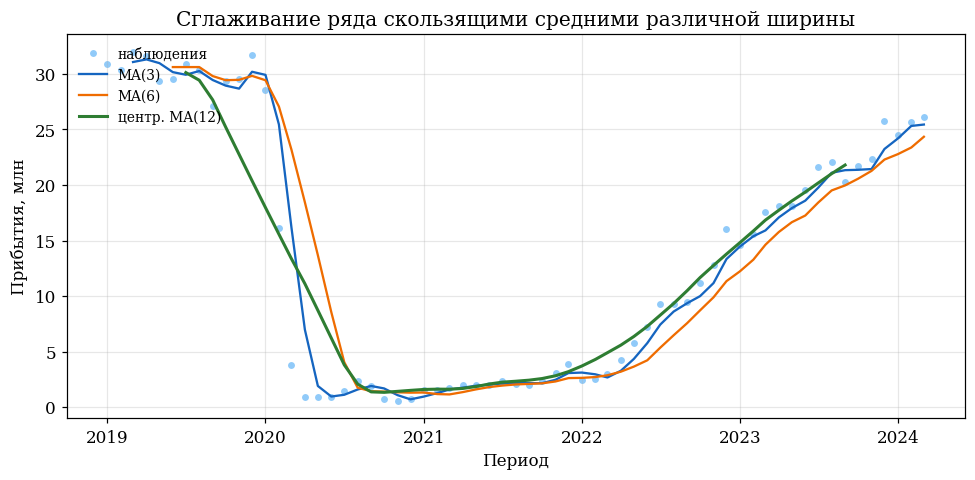

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["arrivals_million"], "o",
        color="#90CAF9", markersize=3.5, label="наблюдения", zorder=1)
ax.plot(df["date"], df["ma_3_month"], "-",
        color="#1565C0", linewidth=1.5, label="MA(3)")
ax.plot(df["date"], df["ma_6_month"], "-",
        color="#EF6C00", linewidth=1.5, label="MA(6)")
ax.plot(df["date"], df["trend_cycle_centered_ma12"], "-",
        color="#2E7D32", linewidth=2.0, label="центр. MA(12)")
ax.set_xlabel("Период")
ax.set_ylabel("Прибытия, млн")
ax.set_title("Сглаживание ряда скользящими средними различной ширины")
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig07_moving_averages.pdf"))
plt.show()

## 11. Аномальные уровни ряда

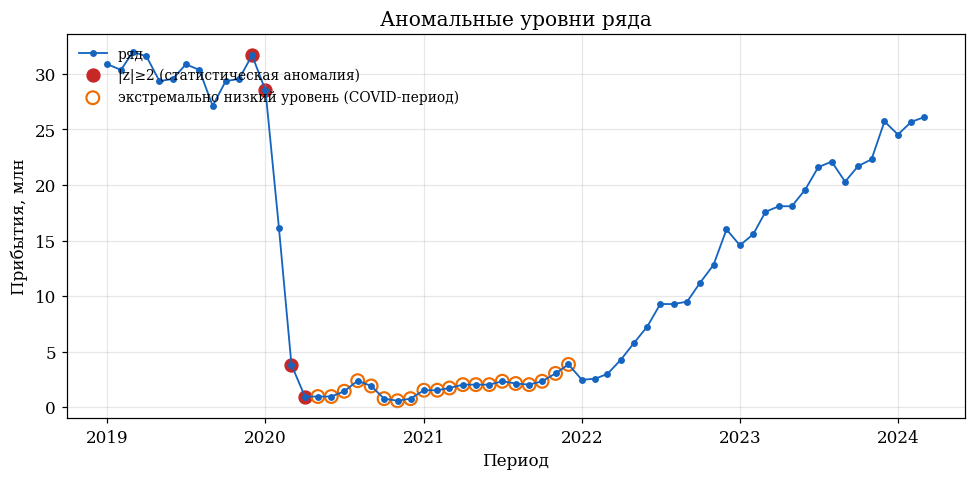

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], df["arrivals_million"], "o-",
        color="#1565C0", markersize=3.5, linewidth=1.2, label="ряд")
flag_z = out_tab[out_tab["residual_flag_abs_z_ge_2"] == True].copy()
flag_z["date"] = pd.to_datetime(flag_z["date"])
ax.scatter(flag_z["date"], flag_z["arrivals_million"],
           color="#C62828", s=70,
           label="|z|≥2 (статистическая аномалия)", marker="o")
flag_covid_only = out_tab[(out_tab["domain_flag_covid_low_level"] == True) &
                          (out_tab["residual_flag_abs_z_ge_2"] == False)].copy()
flag_covid_only["date"] = pd.to_datetime(flag_covid_only["date"])
ax.scatter(flag_covid_only["date"], flag_covid_only["arrivals_million"],
           facecolors="none", edgecolors="#EF6C00", s=70, linewidths=1.4,
           label="экстремально низкий уровень (COVID-период)")
ax.set_xlabel("Период")
ax.set_ylabel("Прибытия, млн")
ax.set_title("Аномальные уровни ряда")
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig08_outliers.pdf"))
plt.show()

## 12. Модели тренда (линейная, параболическая, экспоненциальная)

In [13]:
df_2019_2023 = df[df["year"].between(2019, 2023)].reset_index(drop=True)
t = np.arange(1, len(df_2019_2023) + 1)
y = df_2019_2023["arrivals_million"].values

slope_lin, intercept_lin, r_lin, p_lin, _ = stats.linregress(t, y)
y_lin = intercept_lin + slope_lin * t
r2_lin = r_lin ** 2

coef_quad = np.polyfit(t, y, 2)
y_quad = np.polyval(coef_quad, t)
r2_quad = 1 - np.sum((y - y_quad) ** 2) / np.sum((y - np.mean(y)) ** 2)

df_recov = df[df["date"] >= "2021-01-01"].reset_index(drop=True)
t_r = np.arange(1, len(df_recov) + 1)
y_r = df_recov["arrivals_million"].values
log_y = np.log(y_r[y_r > 0])
t_log = t_r[y_r > 0]
slope_e, intercept_e, r_e, _, _ = stats.linregress(t_log, log_y)
y_exp = np.exp(intercept_e + slope_e * t_r)
r2_exp = r_e ** 2

print(f"Линейная модель:        y = {intercept_lin:.4f} + ({slope_lin:.4f}) · t")
print(f"  R²   = {r2_lin:.4f}")
print(f"  RMSE = {float(np.sqrt(np.mean((y - y_lin) ** 2))):.4f}")
print()
print(f"Параболическая модель:  y = {coef_quad[2]:.4f} + ({coef_quad[1]:.4f}) · t + ({coef_quad[0]:.4f}) · t²")
print(f"  R²   = {r2_quad:.4f}")
print(f"  RMSE = {float(np.sqrt(np.mean((y - y_quad) ** 2))):.4f}")
print()
print(f"Экспоненциальный тренд (с 2021): y = exp({intercept_e:.4f} + ({slope_e:.4f}) · t)")
print(f"  R² (на логарифмах) = {r2_exp:.4f}")

Линейная модель:        y = 17.2796 + (-0.1410) · t
  R²   = 0.0460
  RMSE = 11.1159

Параболическая модель:  y = 40.6537 + (-2.4030) · t + (0.0371) · t²
  R²   = 0.8093
  RMSE = 4.9693

Экспоненциальный тренд (с 2021): y = exp(0.2199 + (0.0877) · t)
  R² (на логарифмах) = 0.9442


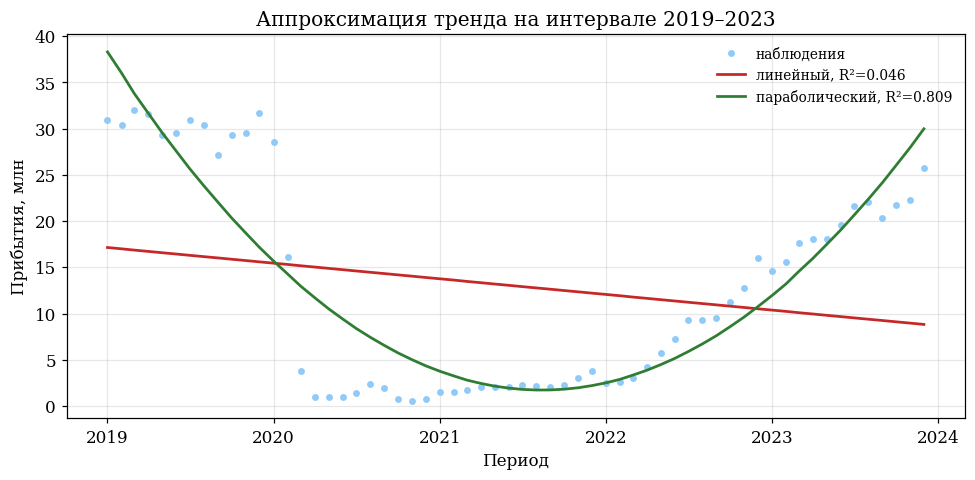

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df_2019_2023["date"], y, "o",
        color="#90CAF9", markersize=3.5, label="наблюдения")
ax.plot(df_2019_2023["date"], y_lin, "-",
        color="#C62828", linewidth=1.8,
        label=f"линейный, R²={r2_lin:.3f}")
ax.plot(df_2019_2023["date"], y_quad, "-",
        color="#2E7D32", linewidth=1.8,
        label=f"параболический, R²={r2_quad:.3f}")
ax.set_xlabel("Период")
ax.set_ylabel("Прибытия, млн")
ax.set_title("Аппроксимация тренда на интервале 2019–2023")
ax.legend(loc="upper right", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig09_trend_models.pdf"))
plt.show()

## 13. Диагностика остаточной компоненты

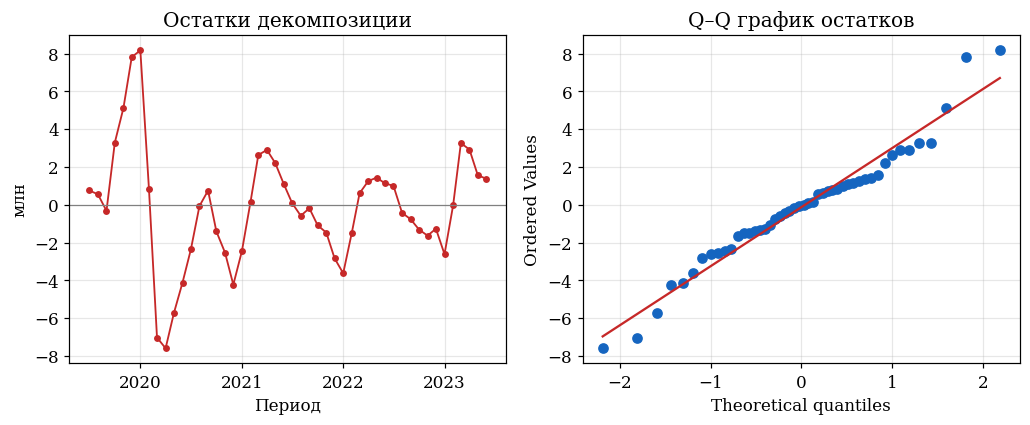

In [15]:
resid = result.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0))
axes[0].plot(resid.index, resid.values, "o-",
             color="#C62828", markersize=3.5, linewidth=1.2)
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].set_title("Остатки декомпозиции")
axes[0].set_xlabel("Период")
axes[0].set_ylabel("млн")
axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

stats.probplot(resid.values, dist="norm", plot=axes[1])
axes[1].set_title("Q–Q график остатков")
axes[1].get_lines()[0].set_markerfacecolor("#1565C0")
axes[1].get_lines()[0].set_markeredgecolor("#1565C0")
axes[1].get_lines()[1].set_color("#C62828")

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig10_residuals.pdf"))
plt.show()

In [16]:
# Шапиро–Уилк
sw_stat, sw_p = stats.shapiro(resid.values)

# Дарбин–Уотсон
def durbin_watson(x):
    return float(np.sum(np.diff(x) ** 2) / np.sum(x ** 2))
dw = durbin_watson(resid.values)

# Критерий поворотных точек
def turning_points(x):
    n = len(x)
    p = 0
    for i in range(1, n - 1):
        if (x[i] > x[i-1] and x[i] > x[i+1]) or (x[i] < x[i-1] and x[i] < x[i+1]):
            p += 1
    expected = 2 * (n - 2) / 3
    var = (16 * n - 29) / 90
    z = (p - expected) / np.sqrt(var)
    return p, expected, var, z

p_tp, p_exp, p_var, p_z = turning_points(resid.values)

print(f"Шапиро–Уилк: W = {sw_stat:.4f}, p = {sw_p:.4f}")
print(f"Дарбин–Уотсон: d = {dw:.4f}")
print(f"Поворотные точки: p = {p_tp}, ожидаемое = {p_exp:.2f}, "
      f"σ = {np.sqrt(p_var):.2f}, z = {p_z:.4f}")

Шапиро–Уилк: W = 0.9664, p = 0.1828
Дарбин–Уотсон: d = 0.4872
Поворотные точки: p = 14, ожидаемое = 30.67, σ = 2.87, z = -5.8163


## 14. Экспоненциальное сглаживание Брауна

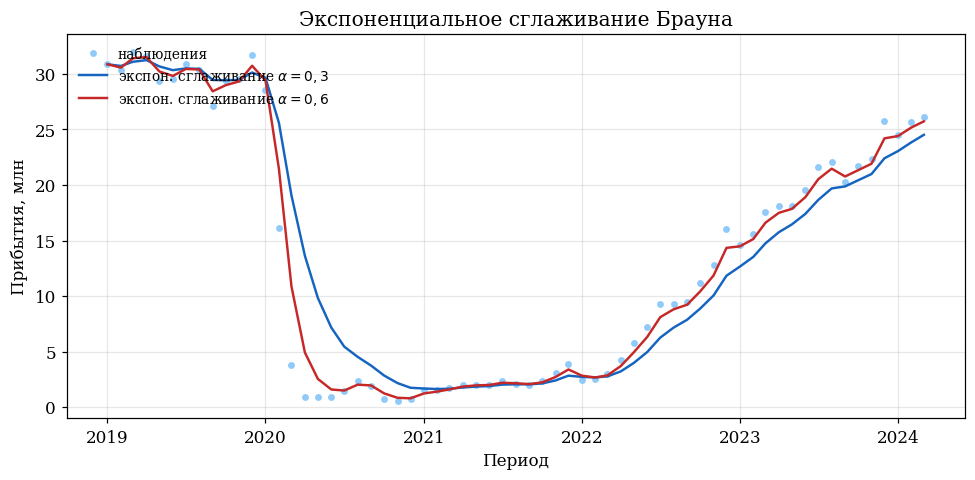

In [17]:
def exp_smooth(x, alpha):
    s = np.zeros_like(x, dtype=float)
    s[0] = x[0]
    for i in range(1, len(x)):
        s[i] = alpha * x[i] + (1 - alpha) * s[i-1]
    return s

y_full = df["arrivals_million"].values
es_03 = exp_smooth(y_full, 0.3)
es_06 = exp_smooth(y_full, 0.6)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["date"], y_full, "o",
        color="#90CAF9", markersize=3.5, label="наблюдения")
ax.plot(df["date"], es_03, "-",
        color="#1565C0", linewidth=1.6, label=r"экспон. сглаживание $\alpha=0,3$")
ax.plot(df["date"], es_06, "-",
        color="#C62828", linewidth=1.6, label=r"экспон. сглаживание $\alpha=0,6$")
ax.set_xlabel("Период")
ax.set_ylabel("Прибытия, млн")
ax.set_title("Экспоненциальное сглаживание Брауна")
ax.legend(loc="upper left", frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fig11_exp_smoothing.pdf"))
plt.show()

In [18]:
# RMSE сравнение методов сглаживания
rmse_ma3 = float(np.sqrt(np.nanmean((df["arrivals_million"] - df["ma_3_month"]) ** 2)))
rmse_ma6 = float(np.sqrt(np.nanmean((df["arrivals_million"] - df["ma_6_month"]) ** 2)))
rmse_ma12 = float(np.sqrt(np.nanmean((df["arrivals_million"] - df["trend_cycle_centered_ma12"]) ** 2)))
rmse_es03 = float(np.sqrt(np.mean((y_full - es_03) ** 2)))
rmse_es06 = float(np.sqrt(np.mean((y_full - es_06) ** 2)))

print("RMSE различных методов сглаживания (млн):")
print(f"  MA(3):              {rmse_ma3:.3f}")
print(f"  MA(6):              {rmse_ma6:.3f}")
print(f"  центр. MA(12):      {rmse_ma12:.3f}")
print(f"  экспон. α=0,3:      {rmse_es03:.3f}")
print(f"  экспон. α=0,6:      {rmse_es06:.3f}")

RMSE различных методов сглаживания (млн):
  MA(3):              2.340
  MA(6):              4.546
  центр. MA(12):      3.484
  экспон. α=0,3:      3.493
  экспон. α=0,6:      1.365


## 15. Сводка сезонной структуры

In [19]:
print("Сезонная структура:")
print(f"  2019 пик:   {season.loc[season['2019_baseline_million'].idxmax(), 'month_name_ru']} "
      f"({season['2019_baseline_million'].max():.3f} млн)")
print(f"  2019 мин:   {season.loc[season['2019_baseline_million'].idxmin(), 'month_name_ru']} "
      f"({season['2019_baseline_million'].min():.3f} млн)")
print(f"  2023 пик:   {season.loc[season['2023_million'].idxmax(), 'month_name_ru']} "
      f"({season['2023_million'].max():.3f} млн)")
print()
print("Изменение доли месяцев в годовом итоге (2023 vs 2019, п.п.):")
top_grew = season.nlargest(3, "share_change_2023_minus_2019_pp")[
    ["month_name_ru", "share_change_2023_minus_2019_pp"]
]
for _, row in top_grew.iterrows():
    print(f"  {row['month_name_ru']:10s}  {row['share_change_2023_minus_2019_pp']:+.2f}")
top_drop = season.nsmallest(3, "share_change_2023_minus_2019_pp")[
    ["month_name_ru", "share_change_2023_minus_2019_pp"]
]
for _, row in top_drop.iterrows():
    print(f"  {row['month_name_ru']:10s}  {row['share_change_2023_minus_2019_pp']:+.2f}")

Сезонная структура:
  2019 пик:   Март (31.985 млн)
  2019 мин:   Сентябрь (27.127 млн)
  2023 пик:   Декабрь (25.723 млн)

Изменение доли месяцев в годовом итоге (2023 vs 2019, п.п.):
  Декабрь     +2.11
  Ноябрь      +1.25
  Сентябрь    +1.08
  Январь      -2.37
  Февраль     -1.81
  Март        -1.41
